In [2]:
from typing import TypedDict, List, Literal, Annotated
from dotenv import load_dotenv

from langgraph.graph import  state, StateGraph, START, END

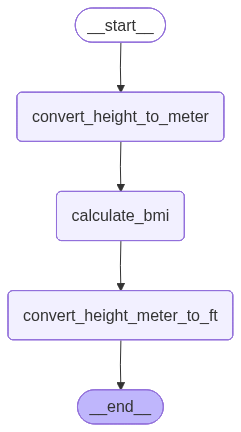

In [34]:
# Define the state 
class StateBMI(TypedDict):
    weight :  Annotated[float, "Weight of the person"]
    height :   Annotated[float, "Height of the person"]
    BMI :  Annotated[float,"BMI of the person"]




def convert_height_to_meter( state : StateBMI) -> StateBMI:
    state['height']=state['height'] * .3048
    return state
    
    


#define the node
def calculate_bmi( state : StateBMI) -> StateBMI:
    
    bmi = state["weight"] / (state["height"] ** 2)

    state['BMI']=round(bmi, 2)
    
    return state


def convert_height_meter_to_ft( state : StateBMI) -> StateBMI:
    state['height']=round(state['height'] / .3048 , 2)
    return state




#define the graph
graph = StateGraph(StateBMI)

#add the node
graph.add_node("convert_height_to_meter", convert_height_to_meter)
graph.add_node("calculate_bmi", calculate_bmi)
graph.add_node("convert_height_meter_to_ft", convert_height_meter_to_ft)

#add the edges
graph.add_edge(START, 'convert_height_to_meter')
graph.add_edge('convert_height_to_meter', "calculate_bmi")
graph.add_edge( "calculate_bmi","convert_height_meter_to_ft")
graph.add_edge('convert_height_meter_to_ft', END)

#compile 
workFlow=graph.compile()
workFlow

In [35]:
workFlow.invoke({'weight':70.0, "height":5.4})

{'weight': 70.0, 'height': 5.4, 'BMI': 25.84}